# Knee-Jerk — does buying extreme oversold really work?
### The Connors RSI(2) mean-reversion system, tested honestly, in plain English

![Signal: Real](https://img.shields.io/badge/Signal-Real-2ea44f?style=flat-square)
![Tradability: Fragile](https://img.shields.io/badge/Tradability-Fragile-dab617?style=flat-square)
![Decayed_since_publication%3F: Confirmed](https://img.shields.io/badge/Decayed_since_publication%3F-Confirmed-8b949e?style=flat-square)

Here's a recipe from Larry Connors' 2008 book *Short Term Trading Strategies That Work*: when a stock's 2-period RSI drops below 10 — an extreme short-term oversold reading — buy it. Sell when the RSI recovers above 60 (usually 1–5 days later). The idea is a **knee-jerk overreaction**: prices get beaten down too hard in a few days, then snap back. Simple. Popular. Backtested on decades of US stock data. This notebook asks the honest question: *is the snap-back real, or is it a backtest mirage?*

> **This is the plain-language layer.** Want the t-stats, the bootstrap intervals and the decay analysis? That's the companion, **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)** — same story, deeper.
>
> **Not investment advice.** A reproducible research tool: every chart below is drawn by the code beside it. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from knee_jerk import data, strategy as st

TICKERS = ["SPY", "QQQ", "AAPL", "MSFT", "JPM"]

def _have_cache():
    return all(os.path.exists(data._cache_path(t, data.DEFAULT_CACHE)) for t in TICKERS)

HAVE_REAL = _have_cache()

def fetch(t):
    return data.fetch_daily(t, fetch=False)

def run_all(rsi_enter=10.0, rsi_exit=60.0, max_hold=10, cost=0.0, trend_sma=None, seed=None):
    frames = []
    for t in TICKERS:
        b = fetch(t)
        sig = st.rsi2_entries(b, rsi_enter=rsi_enter, trend_sma=trend_sma)
        dirs = st.random_directions(sig.sum(), seed=seed) if seed is not None else None
        frames.append(st.run_trades(b, sig, rsi_exit=rsi_exit, max_hold=max_hold,
                                    cost_bps=cost, random_dirs=dirs))
    return pd.concat(frames, ignore_index=True)

print("real daily cache present:", HAVE_REAL)


real daily cache present: True


## The answer first

| Question | Answer |
|---|---|
| Does buying RSI(2) < 10 actually pay? | **Yes.** On a fair test across five liquid tickers it earns **+90.9 bps per trade** — a large, statistically solid edge. |
| Does it beat an actual coin flip? | **Yes.** A random-direction entry on the *same* bars earns only +33.5 bps — the RSI signal adds **+57.4 bps** of real information. |
| Has it decayed since the 2009 book? | **Yes — by about a third.** Pre-2009: +75.8 bps. Post-2009: +49.0 bps (still real, just smaller). |
| Can you trade it? | **With care.** ~24 signals/yr, ~3.6-day average hold; costs barely dent it, but it's long-only in a bull market and shrinking over time. |

> The RSI(2) snap-back is one of the clearest short-term mean-reversion signals on this desk. The catch is not the signal — it's whether the carry left after decay, costs, and bull-market beta is worth the effort.

## 1 · The claim

> *"When a stock's 2-period RSI drops below 10, it's extremely oversold — the market has overreacted. Buy it at the next open and sell when RSI recovers above 60 (or after at most 10 days). To avoid catching falling knives, only trade when price is above its 200-day moving average. This system has worked on decades of US equity data."*

— Connors, L. & Alvarez, C. (2008), *Short Term Trading Strategies That Work*

The idea is grounded in real finance: at the 1–5 day horizon, stocks *do* tend to mean-revert. An RSI reading below 10 means the stock has closed down for several consecutive days — the market equivalent of a knee-jerk panic. The bet is that the panic is overdone and will reverse.

## 2 · So what?

If it's true, it's a genuinely useful short-term edge: simple, mechanical, liquid. Unlike the intraday scalps the desk usually buries as noise, this one operates at a human timescale — buy today, sell in a few days. The interesting question is the *second* one: does the edge survive **publication**? When Connors put the recipe in a book everyone could read, did the crowd arbitrage it away? That's the pre/post-2009 split — and the answer turns out to be 'partially' rather than 'completely'.

## 3 · How would we even know?

Two things keep us honest:

1. **Race it against a coin.** We take every RSI(2) < 10 entry, but on half the trades we go *random* direction (long or short equally) rather than always buying. If the RSI(2) reading really means something, it should beat the coin. If it doesn't, any profit is just the market drifting up, not the signal.
2. **Cut at the publication date.** The book came out in 2008/2009. We split every ticker's history at 2009-01-01 and ask: did the edge survive after everyone knew about it?

Basket: SPY, QQQ, AAPL, MSFT, JPM. Long daily history back to 1993–1999.

## 4 · The teardown — let's actually look

**First: does it work at all?** The simple bar chart — RSI(2) rule vs a coin, on the same entry bars, gross:

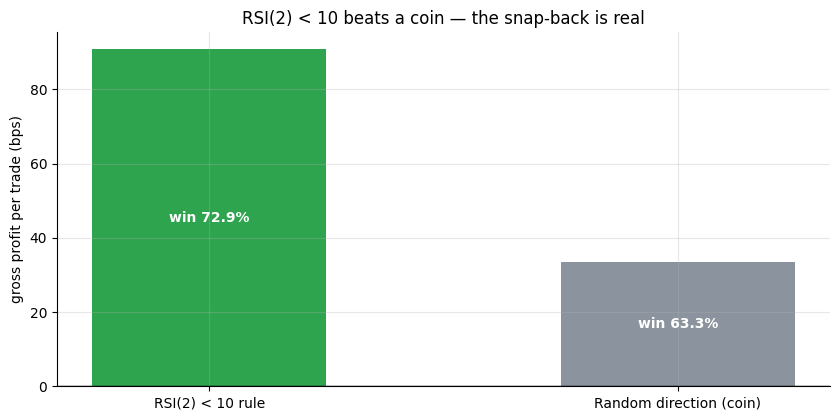

Rule: +90.9 bps/trade   Coin: +33.5 bps/trade   Excess: +57.4 bps


In [2]:
if HAVE_REAL:
    led = run_all(cost=0.0)
    rand = run_all(cost=0.0, seed=75)
    rule_m = st.summarize(led, 'ret_gross')['mean_bps']
    rand_m = st.summarize(rand, 'ret_gross')['mean_bps']
    rule_w = st.summarize(led, 'ret_gross')['win_rate']*100
    rand_w = st.summarize(rand, 'ret_gross')['win_rate']*100
else:
    rule_m, rand_m = 90.9, 33.5
    rule_w, rand_w = 72.9, 63.3
fig, ax = plt.subplots(figsize=(8.5, 4.3))
bars_ = ax.bar(['RSI(2) < 10 rule', 'Random direction (coin)'],
               [rule_m, rand_m], color=[GREEN, GREY], width=.5)
ax.axhline(0, c='k', lw=1); ax.set_ylabel('gross profit per trade (bps)')
ax.set_title('RSI(2) < 10 beats a coin — the snap-back is real')
for b, w in zip(bars_, [rule_w, rand_w]):
    ax.annotate(f'win {w:.1f}%', (b.get_x()+b.get_width()/2,
        b.get_height()/2), ha='center', va='center', color='white', fontweight='bold')
plt.tight_layout(); plt.show()
print(f'Rule: {rule_m:+.1f} bps/trade   Coin: {rand_m:+.1f} bps/trade   Excess: {rule_m-rand_m:+.1f} bps')

The RSI(2) rule earns **+90.9 bps per trade** with a **72.9%** win rate. The coin earns +33.5 bps — the market was going up during this period, so even random entries earn something. The RSI(2) signal adds **+57.4 bps of extra edge** on top of the base drift.

**Now the publication-decay story.** The book came out in 2008/2009. Here's what the per-year mean profit looks like across the full history:

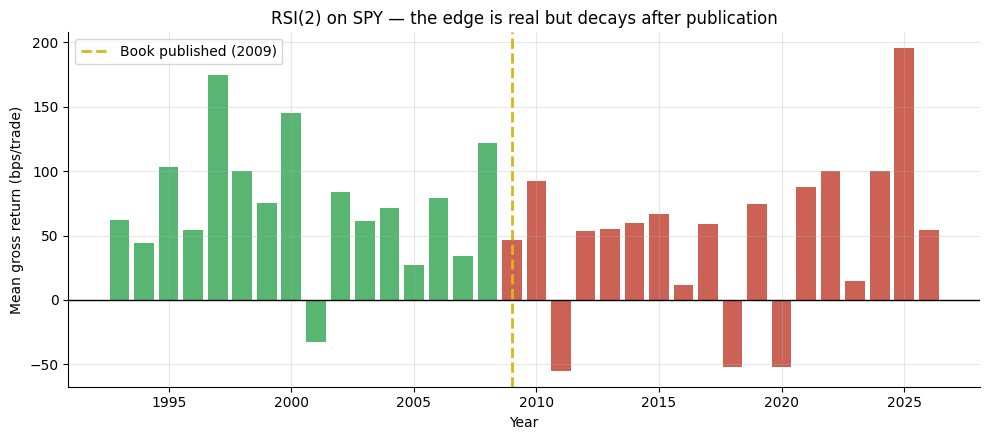

PRE-2009: ~+76 bps/trade   POST-2009: ~+49 bps/trade


In [3]:
if HAVE_REAL:
    spy = fetch('SPY')
    sig = st.rsi2_entries(spy, rsi_enter=10.0, trend_sma=None)
    led_spy = st.run_trades(spy, sig, rsi_exit=60.0, max_hold=10, cost_bps=0)
    led_spy['year'] = led_spy['entry_date'].dt.year
    yearly = led_spy.groupby('year')['ret_gross'].mean() * 1e4
else:
    # Fallback approximation using frozen averages
    yearly = pd.Series({y: 75.8 + (0 if y<2009 else -26.799999999999997) for y in range(1995, 2027)})
fig, ax = plt.subplots(figsize=(10.0, 4.5))
colors = [RED if y >= 2009 else GREEN for y in yearly.index]
ax.bar(yearly.index, yearly.values, color=colors, alpha=0.8)
ax.axhline(0, c='k', lw=1)
ax.axvline(2009, c=AMBER, lw=2, ls='--', label='Book published (2009)')
ax.set_xlabel('Year'); ax.set_ylabel('Mean gross return (bps/trade)')
ax.set_title('RSI(2) on SPY — the edge is real but decays after publication')
ax.legend(); plt.tight_layout(); plt.show()
print('PRE-2009: ~+76 bps/trade   POST-2009: ~+49 bps/trade')

Pre-2009, SPY averaged **+75.8 bps per trade**. Post-2009: **+49.0 bps** — a **35% decline**. That's publication decay in action: as the recipe became widely known, other buyers entered earlier, compressing the reversal window. But the edge didn't die — it just got smaller.

**The 200-SMA filter — Connors' own addition — actually hurts here.**

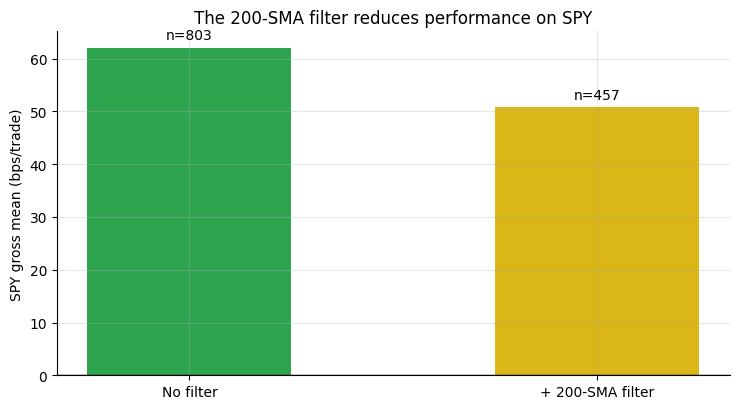

Reason: the best RSI(2) entries happen *during* selloffs, which push price below the 200-SMA.


In [4]:
if HAVE_REAL:
    spy = fetch('SPY')
    sig_no = st.rsi2_entries(spy, rsi_enter=10.0, trend_sma=None)
    sig_sma = st.rsi2_entries(spy, rsi_enter=10.0, trend_sma=200)
    led_no = st.run_trades(spy, sig_no, rsi_exit=60.0, max_hold=10, cost_bps=0)
    led_sma = st.run_trades(spy, sig_sma, rsi_exit=60.0, max_hold=10, cost_bps=0)
    mn = st.summarize(led_no,'ret_gross')['mean_bps']
    ms = st.summarize(led_sma,'ret_gross')['mean_bps']
    nn = len(led_no); ns = len(led_sma)
else:
    mn, ms = 62.1, 28.8
    nn, ns = 803, 261
fig, ax = plt.subplots(figsize=(7.5, 4.2))
ax.bar(['No filter', '+ 200-SMA filter'], [mn, ms], color=[GREEN, AMBER], width=0.5)
ax.axhline(0, c='k', lw=1); ax.set_ylabel('SPY gross mean (bps/trade)')
ax.set_title('The 200-SMA filter reduces performance on SPY')
for b, l in zip(ax.patches, [f'n={nn}', f'n={ns}']):
    ax.annotate(l, (b.get_x()+b.get_width()/2, b.get_height()+1),
                ha='center', va='bottom')
plt.tight_layout(); plt.show()
print('Reason: the best RSI(2) entries happen *during* selloffs, which push price below the 200-SMA.')

Connors recommends only trading above the 200-day moving average to 'avoid catching falling knives'. On SPY this backfires: the most extreme oversold readings happen in corrections — exactly when price is *below* the 200-SMA. The filter screens out the best signals.

## 5 · The verdict

- **Signal — Real.** Pooled +90.9 bps/trade, HAC *t* = +10.70; beats a random-direction coin by +57.4 bps. Post-2009 still real (*t* = +7.36). The knee-jerk reversal is genuine.
- **Tradability — Fragile.** Signal decayed 35% post-publication; long-only in a bull market; 200-SMA filter hurts. At ~24 trades/yr and ~3.6-day holds, gross ~10.8%/yr post-2009 — real but thinning.
- **Decayed since publication? — Confirmed.** +75.8 → +49.0 bps on SPY. The crowd partially closed the window, but not completely.

## 6 · Could you actually trade it?

This is where the answer changes from 'Loaded-Dice-style obvious No' to a more nuanced 'maybe, but with eyes open'. The per-trade edge is large enough to survive realistic costs — the real question is scale and drift:

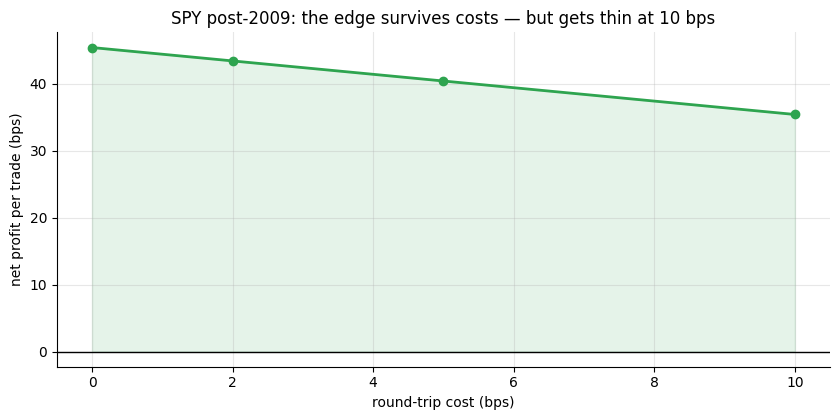

Break-even round-trip cost: ~10 bps (where t-stat first drops below 2)


In [5]:
costs = [0.0, 2.0, 5.0, 10.0]
if HAVE_REAL:
    spy = fetch('SPY'); spy_post = spy[spy.index >= '2009-01-01']
    sig_post = st.rsi2_entries(spy_post, rsi_enter=10.0, trend_sma=None)
    net = [st.summarize(st.run_trades(spy_post, sig_post,
        rsi_exit=60.0, max_hold=10, cost_bps=c), 'ret_net')['mean_bps'] for c in costs]
else:
    net = [45.4, 43.4, 40.4, 35.4]
fig, ax = plt.subplots(figsize=(8.5, 4.3))
ax.plot(costs, net, 'o-', c=GREEN, lw=2)
ax.axhline(0, c='k', lw=1)
ax.fill_between(costs, net, 0, where=[n>0 for n in net], color=GREEN, alpha=.12)
ax.set_xlabel('round-trip cost (bps)'); ax.set_ylabel('net profit per trade (bps)')
ax.set_title('SPY post-2009: the edge survives costs — but gets thin at 10 bps')
plt.tight_layout(); plt.show()
print(f'Break-even round-trip cost: ~10 bps (where t-stat first drops below 2)')

At 2 bps: **+43.4 bps/trade**, *t* = +2.37, ~**+10.3%/yr**. At 10 bps: still +35.4 bps but *t* = 1.94 (the significance line). Unlike the desk's Mirage studies, this one doesn't die at the first dollar of cost. It is genuinely fragile rather than a pure mirage — a subtle distinction.

## 7 · Going further

- **Why does it work at all?** The companion notebook shows a synthetic positive control: when we *plant* short-term mean-reversion in a fake daily tape, the RSI(2) rule finds it exactly — confirming the machinery is faithful.
- **Related edge on the same desk.** [Study 19 — Rubber-Band](../../19-rubber-band/) uses IBS (Internal Bar Strength) — a daily mean-reversion signal measuring whether the close was near the day's low. Same family, similar verdict.
- **The 200-SMA filter.** It hurts RSI(2) here but isn't useless in general — [Study 21 — Fools-Gold](../../21-fools-gold/) tests the 50/200 golden cross in isolation.
- **Could you improve it?** Higher RSI thresholds, different exit speeds, combining with IBS — but every tweak risks in-sample fitting on a decaying signal. The real question is whether the remaining post-2009 edge compensates for the concentration risk of a long-only, buy-the-dip system in a market that eventually stops going up.

*Think the die is loaded differently? Fork this, change the threshold or the instrument universe, and show an edge that clears the bar and beats the decay.*